In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0


GPU available: []


In [2]:
SEED = 42

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Configuration:")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

Configuration:
Image size: (224, 224)
Batch size: 32
Maximum epochs: 20


In [3]:
from pathlib import Path

possible_paths = [
    Path("data/cnn_train"),
    Path("../data/cnn_train"),
    Path("../../data/cnn_train"),
]

if not any(p.is_dir() for p in possible_paths):
    # first run: assemble data/cnn_train/<Country>/*.jpg from the RDD2020 train
    # split. Every image is fully decoded before copying so truncated files are
    # skipped (tf.data fails hard on corrupt JPEGs).
    import shutil
    from PIL import Image

    skipped = []
    for train_cand in (Path("data/train"), Path("../data/train"), Path("../../data/train")):
        if train_cand.is_dir():
            dest = train_cand.parent / "cnn_train"
            for country in sorted(d for d in train_cand.iterdir() if d.is_dir()):
                imgs = country / "images"
                if not imgs.is_dir():
                    continue
                target = dest / country.name
                target.mkdir(parents=True, exist_ok=True)
                for src in sorted(imgs.glob("*.jpg")):
                    try:
                        with Image.open(src) as im:
                            im.load()
                    except Exception:
                        skipped.append(src.name)
                        continue
                    shutil.copy2(src, target / src.name)
            break
    print("skipped corrupt images:", skipped)

TRAIN_DIR = None

for path in possible_paths:
    if path.is_dir():
        TRAIN_DIR = path.resolve()
        break

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Could not find 'cnn_train'. "
        "Please make sure the dataset is inside the 'data' folder."
    )

print("Training directory:")
print(TRAIN_DIR)
print("Exists:", TRAIN_DIR.is_dir())

Training directory:
C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\data\cnn_train
Exists: True


In [4]:
print("Dataset structure")
print("=" * 60)

for item in sorted(TRAIN_DIR.iterdir()):
    if item.is_dir():
        print(f"[CLASS] {item.name}")
    else:
        print(f"[FILE]  {item.name}")

Dataset structure
[CLASS] Czech
[CLASS] India
[CLASS] Japan


In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("\nClass names:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Found 13141 files belonging to 3 classes.


Using 10513 files for training.


Found 13141 files belonging to 3 classes.


Using 2628 files for validation.



Class names: ['Czech', 'India', 'Japan']
Number of classes: 3


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


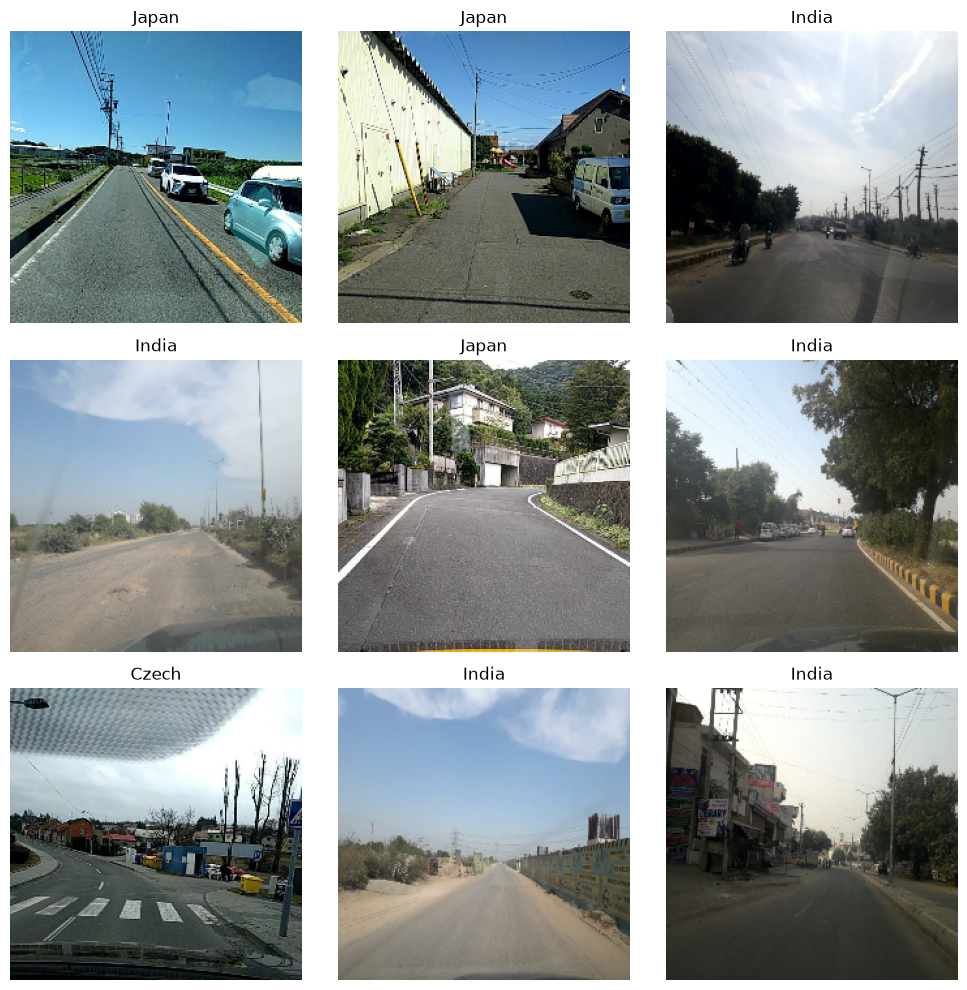

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [11]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/329 ━━━━━━━━━━━━━━━━━━━━ 10:45 2s/step - accuracy: 0.5625 - loss: 1.0862

  2/329 ━━━━━━━━━━━━━━━━━━━━ 3:09 580ms/step - accuracy: 0.5312 - loss: 1.7323

  3/329 ━━━━━━━━━━━━━━━━━━━━ 3:08 578ms/step - accuracy: 0.5625 - loss: 1.4772

...

328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9998 - loss: 5.8937e-04

329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9998 - loss: 5.8850e-04

329/329 ━━━━━━━━━━━━━━━━━━━━ 227s 690ms/step - accuracy: 0.9998 - loss: 5.8850e-04 - val_accuracy: 0.9989 - val_loss: 0.0086 - learning_rate: 1.6000e-06


Epoch 19: early stopping


Restoring model weights from the end of the best epoch: 14.


In [12]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nCustom CNN Validation Results")
print("=" * 50)
print(f"Validation Loss     : {validation_loss:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")

 1/83 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 1.0000 - loss: 1.5274e-07

 2/83 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 1.0000 - loss: 0.0108    

 3/83 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 1.0000 - loss: 0.0075

 4/83 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 1.0000 - loss: 0.0058

 5/83 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 1.0000 - loss: 0.0047 

...

80/83 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9988 - loss: 0.0080

81/83 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9988 - loss: 0.0079

82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9989 - loss: 0.0078

83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.9989 - loss: 0.0078



Custom CNN Validation Results
Validation Loss     : 0.0078
Validation Accuracy : 0.9989


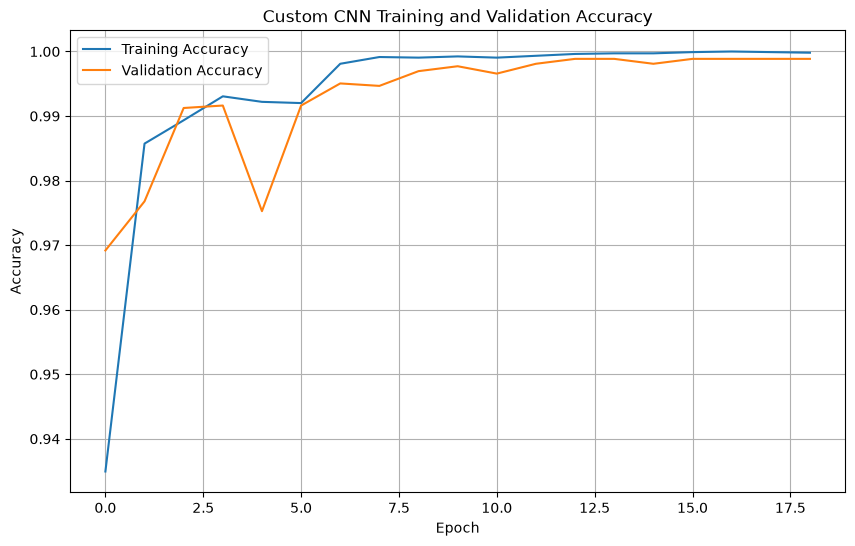

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

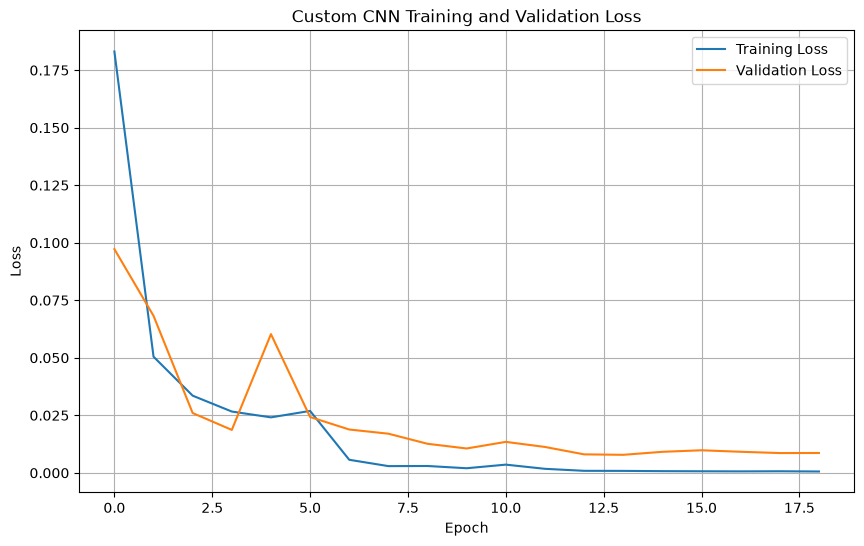

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [15]:
print("Final Custom CNN Results")
print("=" * 50)

print(
    f"Best Validation Accuracy: "
    f"{max(history.history['val_accuracy']):.4f}"
)

print(
    f"Best Validation Loss: "
    f"{min(history.history['val_loss']):.4f}"
)

print(
    f"Final Training Accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)

print(
    f"Final Validation Accuracy: "
    f"{history.history['val_accuracy'][-1]:.4f}"
)

print(
    f"Final Training Loss: "
    f"{history.history['loss'][-1]:.4f}"
)

print(
    f"Final Validation Loss: "
    f"{history.history['val_loss'][-1]:.4f}"
)


# Create results folder (per-member: results/IT23331518)
RESULTS_DIR = next(
    (p for p in (Path("results/IT23331518"),
                 Path("../results/IT23331518"),
                 Path("../../results/IT23331518"))
     if p.parent.is_dir()),
    Path("results/IT23331518"),
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# Save the TRAINED model
model_path = RESULTS_DIR / "custom_cnn_model.keras"

model.save(model_path)

print("\nTrained Custom CNN model saved successfully:")
print(model_path)

Final Custom CNN Results
Best Validation Accuracy: 0.9989
Best Validation Loss: 0.0078
Final Training Accuracy: 0.9998
Final Validation Accuracy: 0.9989
Final Training Loss: 0.0006
Final Validation Loss: 0.0086



Trained Custom CNN model saved successfully:
..\..\results\IT23331518\custom_cnn_model.keras


In [16]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.999809741973877
Final Validation Accuracy: 0.9988584518432617
Final Training Loss: 0.0005884982529096305
Final Validation Loss: 0.008628029376268387
